# Chargement et exploration des données

In [ ]:
import pandas as pd #Manipulation des données
import numpy as np #Algèbre linéaire
import matplotlib.pyplot as plt #Visualisation des données
import seaborn as sns #Visualisation des données
df = pd.read_csv('PJME_hourly.csv')

In [ ]:
print(df) #Affichage des données

                   Datetime  PJME_MW
0       2002-12-31 01:00:00  26498.0
1       2002-12-31 02:00:00  25147.0
2       2002-12-31 03:00:00  24574.0
3       2002-12-31 04:00:00  24393.0
4       2002-12-31 05:00:00  24860.0
...                     ...      ...
145361  2018-01-01 20:00:00  44284.0
145362  2018-01-01 21:00:00  43751.0
145363  2018-01-01 22:00:00  42402.0
145364  2018-01-01 23:00:00  40164.0
145365  2018-01-02 00:00:00  38608.0

[145366 rows x 2 columns]


In [ ]:
print(df.info()) #Affichage des types des données

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB
None


In [ ]:
print(df.describe()) #Affichage des variables statistiques

             PJME_MW
count  145366.000000
mean    32080.222831
std      6464.012166
min     14544.000000
25%     27573.000000
50%     31421.000000
75%     35650.000000
max     62009.000000


In [ ]:
df=df.set_index('Datetime') #Indexation de la colonne Datetime

In [ ]:
df.index=pd.to_datetime(df.index) #Conversion du type d'un objet vers datetime

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB
None


# Visualisation de données

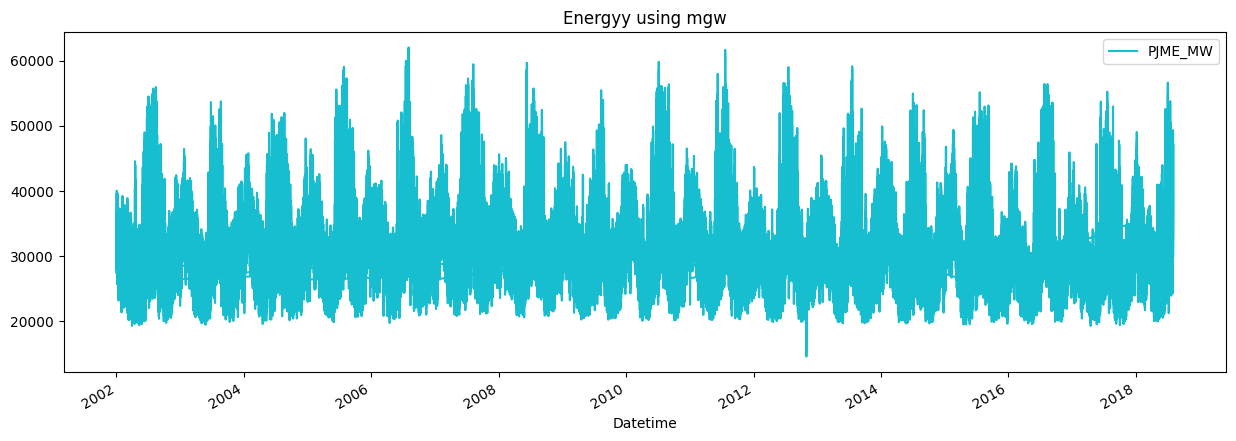

In [ ]:
color_pal = sns.color_palette()
df.plot(figsize=(15,5),style= '-',color=color_pal[9], title='Energyy using mgw')
plt.show()

In [ ]:
#Séparation des données pour les exploiter en autres visualisations
df['Hour']=df.index.hour
df['DayOfWeek']=df.index.dayofweek
df['Month']=df.index.month
df['Quarter']=df.index.quarter
df['Year']=df.index.year
df['DayOfYear']=df.index.dayofyear

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   PJME_MW    145366 non-null  float64
 1   Hour       145366 non-null  int32  
 2   DayOfWeek  145366 non-null  int32  
 3   Month      145366 non-null  int32  
 4   Quarter    145366 non-null  int32  
 5   Year       145366 non-null  int32  
 6   DayOfYear  145366 non-null  int32  
dtypes: float64(1), int32(6)
memory usage: 5.5 MB


In [ ]:
df

,PJME_MW,Hour,DayOfWeek,Month,Quarter,Year,DayOfYear
Datetime,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,12,4,2002,365
2002-12-31 02:00:00,25147.0,2,1,12,4,2002,365
2002-12-31 03:00:00,24574.0,3,1,12,4,2002,365
2002-12-31 04:00:00,24393.0,4,1,12,4,2002,365
2002-12-31 05:00:00,24860.0,5,1,12,4,2002,365
...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1


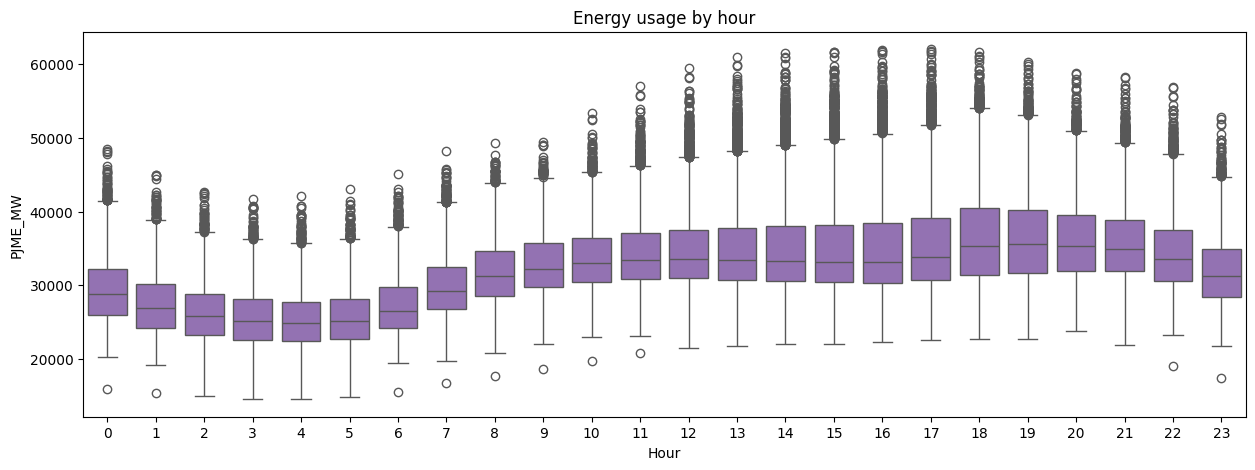

In [ ]:
#Affichage d'un boxplot de la consommation en fonction des heures
color_pal = sns.color_palette()
plt.subplots(figsize=(15,5))
sns.boxplot(data= df, x='Hour',y='PJME_MW', color=color_pal[4])
plt.title('Energy usage by hour')
plt.show()

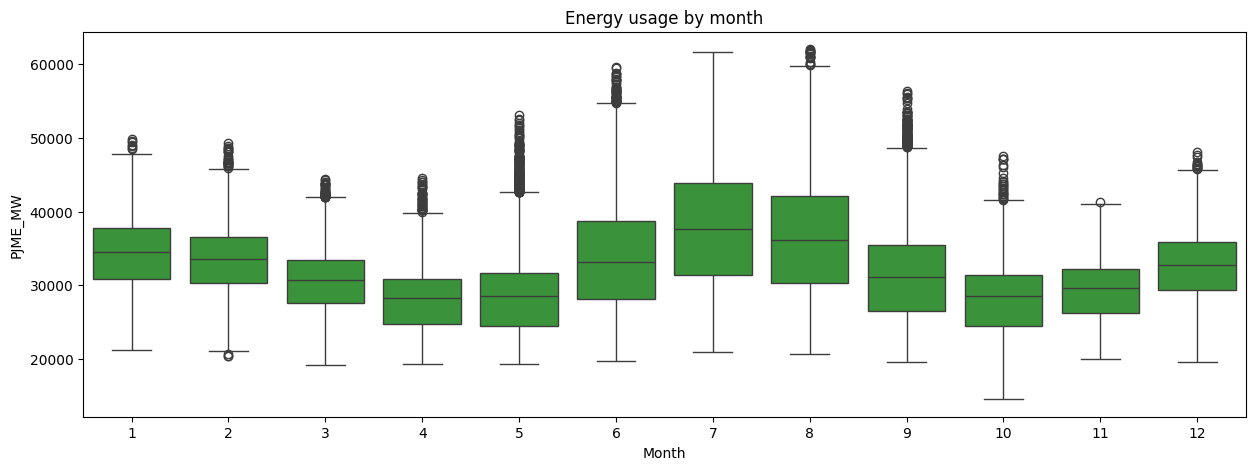

In [ ]:
#Affichage d'un boxplot de la consommation en fonction des mois
color_pal = sns.color_palette()
plt.subplots(figsize=(15,5))
sns.boxplot(data= df, x='Month',y='PJME_MW', color=color_pal[2])
plt.title('Energy usage by month')
plt.show()

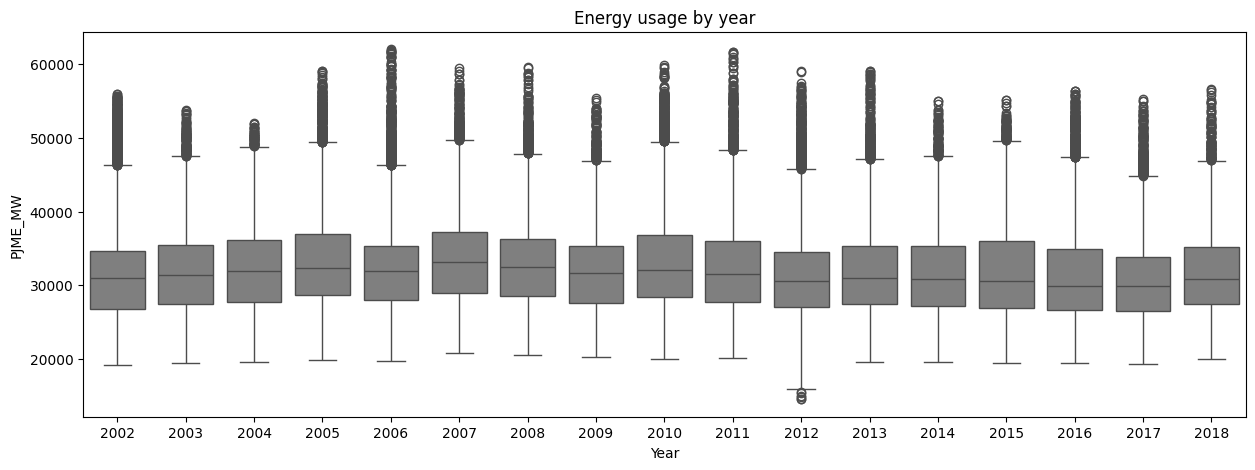

In [ ]:
#Affichage d'un boxplot de la consommation en fonction des années
color_pal = sns.color_palette()
plt.subplots(figsize=(15,5))
sns.boxplot(data= df, x='Year',y='PJME_MW', color=color_pal[7])
plt.title('Energy usage by year')
plt.show()

# Machine Learning

In [ ]:
#Training with XGBoost

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
#Séparer la dataframe en train set (avant 2015) et test set (après 2015)
train_set=df.loc[df.index< '2015-01-01']
test_set=df.loc[df.index>='2015-01-01']

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


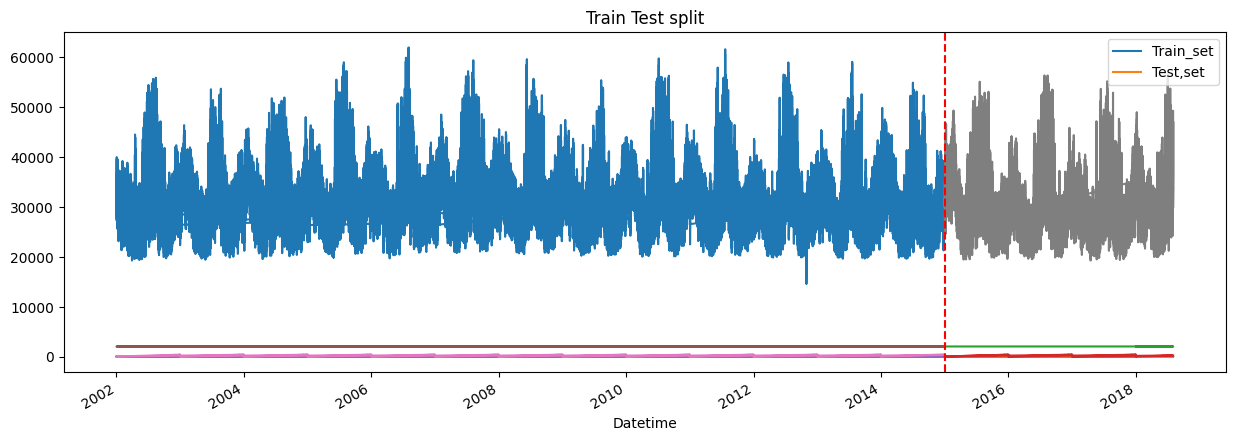

In [ ]:
#Visualiser la partie train_set et test_set
fig,ax=plt.subplots(figsize=(15,5))
train_set.plot(ax=ax)
test_set.plot(ax=ax)
ax.axvline('2015-01-01',color='red', ls='--')
plt.legend(['Train_set','Test,set'])
plt.title('Train Test split')
plt.show()

In [ ]:
df

,PJME_MW,Hour,DayOfWeek,Month,Quarter,Year,DayOfYear
Datetime,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,12,4,2002,365
2002-12-31 02:00:00,25147.0,2,1,12,4,2002,365
2002-12-31 03:00:00,24574.0,3,1,12,4,2002,365
2002-12-31 04:00:00,24393.0,4,1,12,4,2002,365
2002-12-31 05:00:00,24860.0,5,1,12,4,2002,365
...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1


In [ ]:
#séparer les train_set et test_set en fonction des axes des abscisses et d'ordonnées
x_train_xgb=train_set.drop('PJME_MW',axis=1)
y_train_xgb=train_set['PJME_MW']

x_test_xgb=test_set.drop('PJME_MW',axis=1)
y_test_xgb=test_set['PJME_MW']

In [ ]:
x_train_xgb

,Hour,DayOfWeek,Month,Quarter,Year,DayOfYear
Datetime,,,,,,
2002-12-31 01:00:00,1,1,12,4,2002,365
2002-12-31 02:00:00,2,1,12,4,2002,365
2002-12-31 03:00:00,3,1,12,4,2002,365
2002-12-31 04:00:00,4,1,12,4,2002,365
2002-12-31 05:00:00,5,1,12,4,2002,365
...,...,...,...,...,...,...
2014-01-01 20:00:00,20,2,1,1,2014,1
2014-01-01 21:00:00,21,2,1,1,2014,1
2014-01-01 22:00:00,22,2,1,1,2014,1


In [ ]:
y_train_xgb

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2014-01-01 20:00:00,36193.0
2014-01-01 21:00:00,35601.0
2014-01-01 22:00:00,34242.0


In [ ]:
#initialiser et préparer le model XGBoost Regressor
model = XGBRegressor(n_estimator=1000, early_stopping_round=50)

In [ ]:
#Entraîner le model
model.fit(x_train_xgb,y_train_xgb)

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [17:04:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "early_stopping_round", "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_round=50,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimator=1000, n_estimators=None, ...)

In [ ]:
model.score(x_train_xgb,y_train_xgb)

0.9324661462266746

In [ ]:
y_pre=model.predict(x_test_xgb)

In [ ]:
#Évaluer le model
mse = mean_squared_error(y_pre,y_test_xgb)
rmse = np.sqrt(mean_squared_error(y_pre, y_test_xgb))
mae = mean_absolute_error(y_pre, y_test_xgb)
mape = mean_absolute_percentage_error(y_pre, y_test_xgb)
r2 = r2_score(y_pre, y_test_xgb)
print(f'Le MSE est : {mse}')
print(f'Le RMSE est : {rmse}')
print(f'Le MAE est : {mae}')
print(f'Le MAPE est : {mape}')
print(f'Le R2 est : {r2}')

Le MSE est : 17586869.156182434
Le RMSE est : 4193.67012963376
Le MAE est : 3145.5914727208574
Le MAPE est : 0.0975764450077546
Le R2 est : 0.4609722488237227


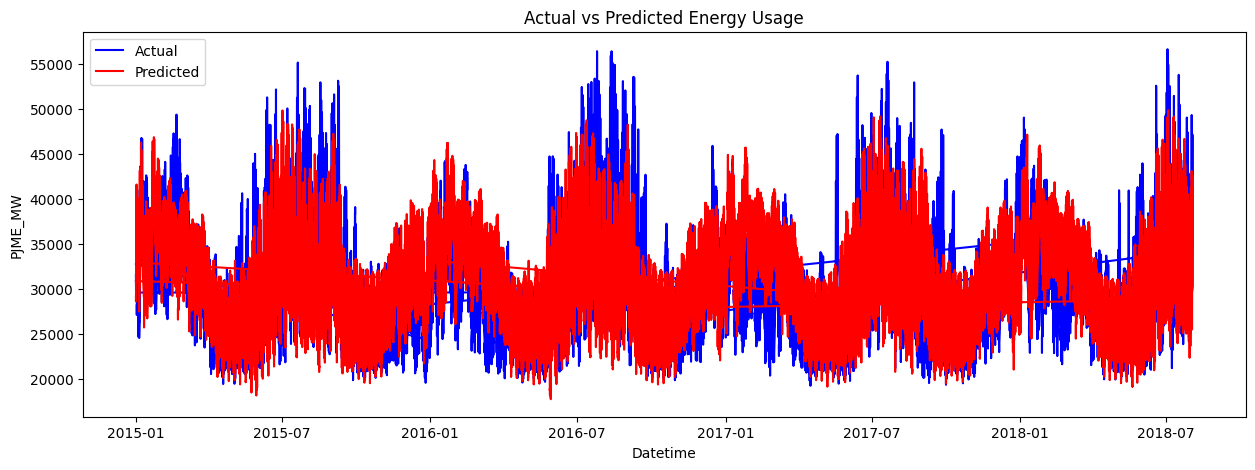

In [ ]:
#Visualiser les données qu'on a prédit et les données réelles
plt.figure(figsize=(15, 5))
plt.plot(y_test_xgb.index, y_test_xgb, label='Actual', color='blue')
plt.plot(y_test_xgb.index, y_pre, label='Predicted', color='red')
plt.title('Actual vs Predicted Energy Usage')
plt.xlabel('Datetime')
plt.ylabel('PJME_MW')
plt.legend()
plt.show()

In [ ]:
# training with Random Forest regressor
#le même process que XGBoost regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
x_train_rfr=train_set.drop('PJME_MW',axis=1)
y_train_rfr=train_set['PJME_MW']

x_test_rfr=test_set.drop('PJME_MW',axis=1)
y_test_rfr=test_set['PJME_MW']

In [ ]:
rfr = RandomForestRegressor(n_estimators=1000, random_state=42)

In [ ]:
rfr.fit(x_train_rfr, y_train_rfr)

RandomForestRegressor(n_estimators=1000, random_state=42)

In [ ]:
model.score(x_train_rfr,y_train_rfr)

0.9324661462266746

In [ ]:
y_pred_rfr = rfr.predict(x_test_rfr)

In [ ]:
np.sqrt(mean_squared_error(y_pred_rfr,y_test_rfr))

np.float64(4337.429807029229)

In [ ]:
mse = mean_squared_error(y_pred_rfr,y_test_rfr)
rmse = np.sqrt(mean_squared_error(y_pred_rfr, y_test_rfr))
mae = mean_absolute_error(y_pred_rfr, y_test_rfr)
mape = mean_absolute_percentage_error(y_pred_rfr, y_test_rfr)
r2 = r2_score(y_pred_rfr, y_test_rfr)
print(f'Le MSE est : {mse}')
print(f'Le RMSE est : {rmse}')
print(f'Le MAE est : {mae}')
print(f'Le MAPE est : {mape}')
print(f'Le R2 est : {r2}')

Le MSE est : 18813297.330905613
Le RMSE est : 4337.429807029229
Le MAE est : 3195.586101352733
Le MAPE est : 0.09826553665663369
Le R2 est : 0.44754711712623774


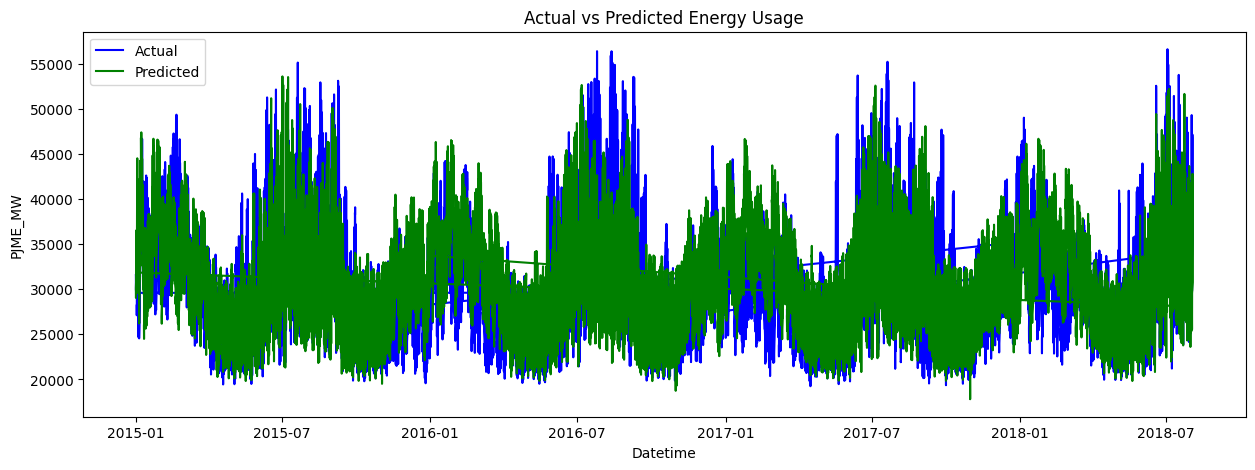

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(y_test_rfr.index, y_test_rfr, label='Actual', color='blue')
plt.plot(y_test_rfr.index, y_pred_rfr, label='Predicted', color='green')
plt.title('Actual vs Predicted Energy Usage')
plt.xlabel('Datetime')
plt.ylabel('PJME_MW')
plt.legend()
plt.show()

In [ ]:
# training with linear regression
# le même process que XGBoost regressor

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
x_train_lr = train_set.drop('PJME_MW', axis=1)
y_train_lr = train_set['PJME_MW']

x_test_lr = test_set.drop('PJME_MW', axis=1)
y_test_lr = test_set['PJME_MW']

In [ ]:
lr_model = LinearRegression()
lr_model.fit(x_train_lr, y_train_lr)

LinearRegression()

In [ ]:
y_pred_lr = lr_model.predict(x_test_lr)

In [ ]:
model.score(x_train_lr,y_train_lr)

0.9324661462266746

In [ ]:
mse = mean_squared_error(y_pred_lr,y_test_lr)
rmse = np.sqrt(mean_squared_error(y_pred_lr, y_test_lr))
mae = mean_absolute_error(y_pred_lr, y_test_lr)
mape = mean_absolute_percentage_error(y_pred_lr, y_test_lr)
r2 = r2_score(y_pred_lr, y_test_lr)
print(f'Le MSE est : {mse}')
print(f'Le RMSE est : {rmse}')
print(f'Le MAE est : {mae}')
print(f'Le MAPE est : {mape}')
print(f'Le R2 est : {r2}')

Le MSE est : 32307292.966642343
Le RMSE est : 5683.950471867462
Le MAE est : 4600.34963461278
Le MAPE est : 0.14322853593960705
Le R2 est : -1.7310293052248942


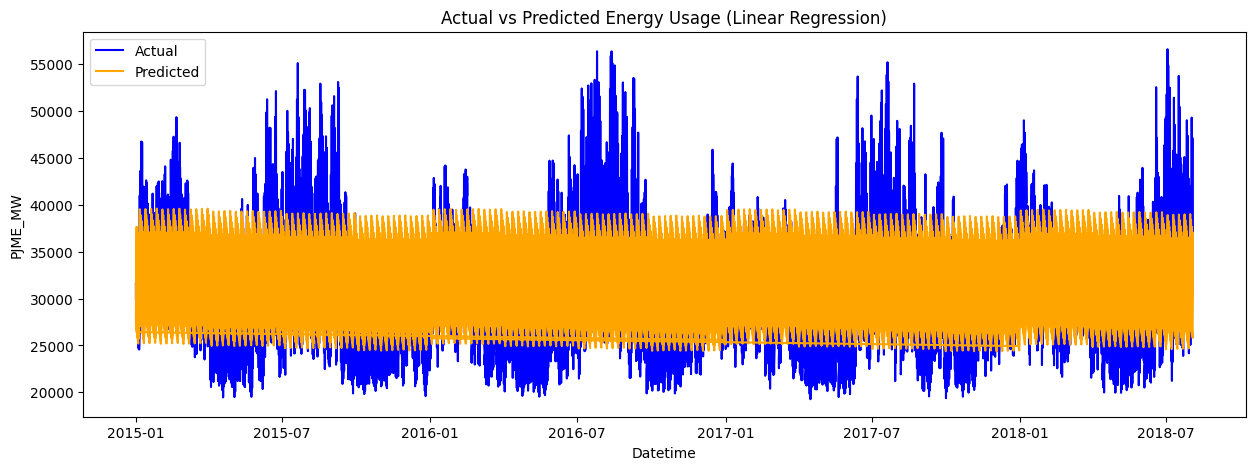

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(y_test_lr.index, y_test_lr, label='Actual', color='blue')
plt.plot(y_test_lr.index, y_pred_lr, label='Predicted', color='orange')
plt.title('Actual vs Predicted Energy Usage (Linear Regression)')
plt.xlabel('Datetime')
plt.ylabel('PJME_MW')
plt.legend()
plt.show()